Caption numbers for Fig. 3:
- At 50% coverage, Critical reduces travel time by 14.9 additional percentage points compared with Random.
- At 50% coverage, Critical reduces CO2 emissions by 4.9 additional percentage points compared with Random.


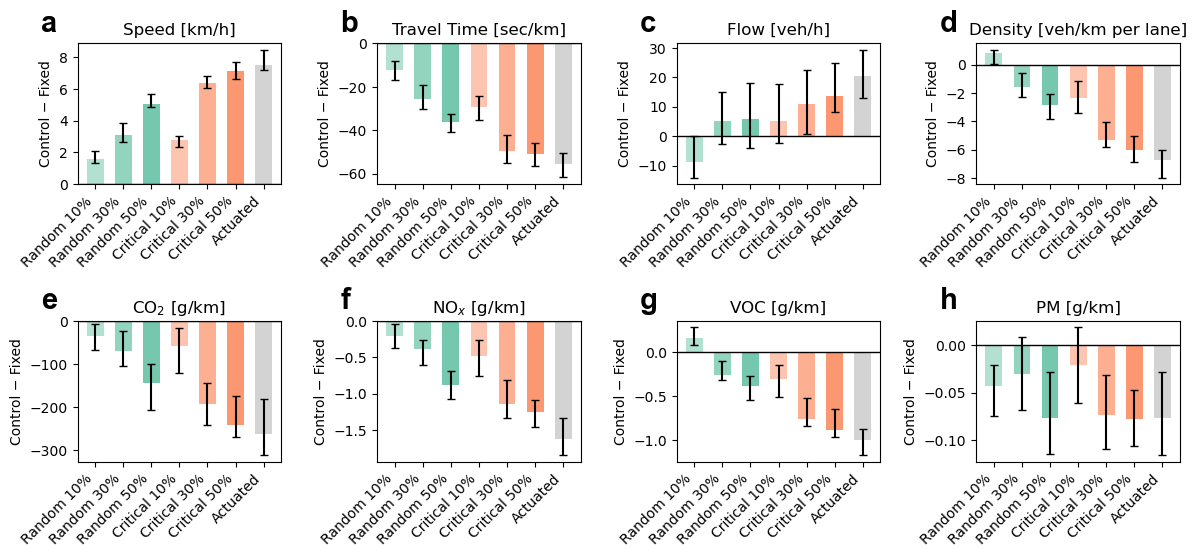

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. Load metrics from saved aimsun parquet
# =========================================================
def load_aimsun_metric_summary(plan_name):
    """
    Read {plan_name}_aimsun.parquet and return one row per rep.

    rep = -1 is excluded because it is the mean case.
    Each value is averaged over all links and times.
    """

    path = f"../data/processed/{plan_name}_aimsun.parquet"
    df = pd.read_parquet(path)

    # only use original repetitions
    df = df[df["rep"] != -1].copy()

    # rename to match plotting metric names
    df = df.rename(columns={
        "flow": "mfd",
        "CO2_interurban": "co2",
        "NOx_interurban": "nox",
        "VOC_interurban": "voc",
        "PM_interurban": "pm",
    })

    metrics = ["mfd", "density", "speed", "ttime", "co2", "nox", "voc", "pm"]

    summary = (
        df.groupby("rep")[metrics]
          .mean()
          .reset_index()
    )

    return summary


# =========================================================
# 2. Difference: scenario - Fix
# =========================================================
def diff_iqr_from_df(df_scn, df_fix, metric):
    """
    Compute per-rep difference between scenario and Fix:
        scenario - Fix

    Return:
        median, median - p25, p75 - median
    """

    merged = pd.merge(
        df_scn[["rep", metric]],
        df_fix[["rep", metric]],
        on="rep",
        suffixes=("_scn", "_fix")
    )

    d = merged[f"{metric}_scn"] - merged[f"{metric}_fix"]

    p25, p50, p75 = np.nanpercentile(d, [25, 50, 75])
    return p50, p50 - p25, p75 - p50


# =========================================================
# 3. Scenario list
# =========================================================
scenario_names = [
    "Random_0.1",
    "Random_0.5",
    "Random_1",
    "Critical_0.1",
    "Critical_0.5",
    "Critical_1",
    "Fix",
    "Actuated",
]

scenarios = {
    name: load_aimsun_metric_summary(name)
    for name in scenario_names
}


# =========================================================
# 4. Plot settings
# =========================================================
metrics = ["speed", "ttime", "mfd", "density", "co2", "nox", "voc", "pm"]

metric_labels = [
    "Speed [km/h]",
    "Travel Time [sec/km]",
    "Flow [veh/h]",
    "Density [veh/km per lane]",
    "CO$_2$ [g/km]",
    "NO$_x$ [g/km]",
    "VOC [g/km]",
    "PM [g/km]",
]

set2 = plt.cm.Set2.colors

color_map = {
    "Random_0.1": (set2[0], 0.5),
    "Random_0.5": (set2[0], 0.7),
    "Random_1":   (set2[0], 0.9),

    "Critical_0.1": (set2[1], 0.5),
    "Critical_0.5": (set2[1], 0.7),
    "Critical_1":   (set2[1], 0.9),

    "Actuated": ("lightgrey", 1.0),
}

rename_map = {
    "Random_0.1": "Random 10%",
    "Random_0.5": "Random 30%",
    "Random_1":   "Random 50%",

    "Critical_0.1": "Critical 10%",
    "Critical_0.5": "Critical 30%",
    "Critical_1":   "Critical 50%",

    "Actuated": "Actuated",
}

plot_order = [name for name in scenario_names if name != "Fix"]


# =========================================================
# 5. Precompute statistics
# =========================================================
fix_df = scenarios["Fix"]

stats = {}

for metric in metrics:
    rows = []

    for name in plot_order:
        y, lo, hi = diff_iqr_from_df(
            scenarios[name],
            fix_df,
            metric
        )
        rows.append((name, y, lo, hi))

    stats[metric] = (
        pd.DataFrame(rows, columns=["name", "y", "lo", "hi"])
          .set_index("name")
    )


# =========================================================
# 6. Caption numbers: Critical 50% versus Random 50%
# =========================================================
def paired_percent_reduction(control_df, fixed_df, metric):
    """Return per-rep percent reduction relative to Fixed for lower-is-better metrics."""
    merged = pd.merge(
        control_df[["rep", metric]],
        fixed_df[["rep", metric]],
        on="rep",
        suffixes=("_control", "_fixed"),
    )
    return (
        (merged[f"{metric}_fixed"] - merged[f"{metric}_control"])
        / merged[f"{metric}_fixed"]
        * 100
    )


def additional_reduction_pp(critical_name, random_name, metric):
    critical_reduction = paired_percent_reduction(scenarios[critical_name], fix_df, metric)
    random_reduction = paired_percent_reduction(scenarios[random_name], fix_df, metric)
    critical_median = float(np.nanmedian(critical_reduction))
    random_median = float(np.nanmedian(random_reduction))
    return {
        "critical_median_pct": critical_median,
        "random_median_pct": random_median,
        "additional_pp": critical_median - random_median,
    }


fig3_caption_numbers = {
    "travel_time_critical50_vs_random50_pp": additional_reduction_pp(
        "Critical_1",
        "Random_1",
        "ttime",
    ),
    "co2_critical50_vs_random50_pp": additional_reduction_pp(
        "Critical_1",
        "Random_1",
        "co2",
    ),
}

print("Caption numbers for Fig. 3:")
print(
    "- At 50% coverage, Critical reduces travel time by "
    f"{fig3_caption_numbers['travel_time_critical50_vs_random50_pp']['additional_pp']:.1f} "
    "additional percentage points compared with Random."
)
print(
    "- At 50% coverage, Critical reduces CO2 emissions by "
    f"{fig3_caption_numbers['co2_critical50_vs_random50_pp']['additional_pp']:.1f} "
    "additional percentage points compared with Random."
)


# =========================================================
# 7. Plot
# =========================================================
fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharey=False)
axes = axes.ravel()

width = 0.6

for ax, metric, label in zip(axes, metrics, metric_labels):

    S = stats[metric].loc[plot_order]

    for x, name in enumerate(S.index):
        color, alpha = color_map[name]

        ax.bar(
            x,
            S.loc[name, "y"],
            yerr=[[S.loc[name, "lo"]], [S.loc[name, "hi"]]],
            capsize=3,
            color=color,
            alpha=alpha,
            width=width,
            linewidth=0,
            edgecolor="black",
        )

    ax.axhline(0, linewidth=1, color="black")
    ax.set_title(label)
    ax.set_ylabel("Control − Fixed")

    ax.set_xticks(range(len(S.index)))
    ax.set_xticklabels(
        [rename_map.get(idx, idx) for idx in S.index],
        rotation=45,
        ha="right"
    )

for ax, panel_label in zip(axes, list("abcdefgh")):
    ax.text(
        -0.18,
        1.04,
        panel_label,
        transform=ax.transAxes,
        fontsize=21.0,
        fontfamily="Arial",
        fontweight="heavy",
        color="black",
        ha="left",
        va="bottom",
        clip_on=False,
    )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../figure/fig3_panel.pdf", dpi=300, bbox_inches="tight")
plt.show()